In [1]:
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

### pupil size

In [ ]:
video_path = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250909/2025-09-29_n098.avi'
output_path = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250909/resluts'
# video_path = '/home/lsh/Data_attention/Neuropixels/Project1_Saliency_map/behavioral_data/J7/test/2025-04-27_RF46_20250427.avi'
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print('Error: Unable to open video file')
    exit()
stack = []
while True:
    ret, frame = cap.read()
    if not ret:
        break 
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY,(width//2, height//2))
    stack.append(gray_frame)

stack = np.array(stack)

Error: Unable to open video file


: 

In [ ]:
import cv2
import os

video_path = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250909/2025-09-29_n098.avi'
output_path = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/N098/20250909/results'
os.makedirs(output_path, exist_ok=True)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print('Error: Unable to open video file')
    exit()

ret, frame = cap.read()
if ret:
    # 转灰度
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # 如果想缩小尺寸，可以用 resize
    height, width = gray_frame.shape
    gray_frame_small = cv2.resize(gray_frame, (width//2, height//2))
    
    # 保存第一帧
    first_frame_path = os.path.join(output_path, 'first_frame.png')
    cv2.imwrite(first_frame_path, gray_frame_small)
    print(f'First frame saved to {first_frame_path}')
else:
    print('Failed to read the first frame')

cap.release()


Error: Unable to open video file
Failed to read the first frame


: 

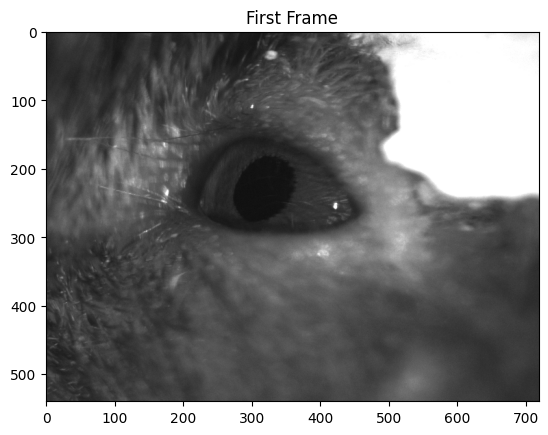

In [4]:
face_image = stack[0]
face_rgb = cv2.cvtColor(face_image, cv2.COLOR_GRAY2RGB)
plt.imshow(face_rgb)
plt.title('First Frame')
plt.axis('on') 
plt.show()

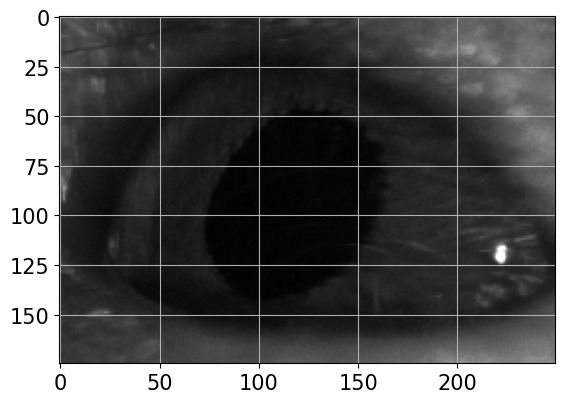

In [13]:
top, left, bottom, right = 135, 200, 310, 450
pupil_image = face_image[top:bottom, left:right]
show_one_image(pupil_image)

In [5]:
def show_one_image(image: np.ndarray, 
                   cmap='gray', colorbar=False, title=None) -> None:
    '''
    show one image
    '''
    figsize = (5, 5)
    fontsize = np.min(figsize) * 3
    plt.rc('xtick', labelsize=fontsize)
    plt.rc('ytick', labelsize=fontsize)
    fig, ax = plt.subplots()
    ax.imshow(image, cmap=cmap, aspect='equal')
    ax.grid()
    if colorbar:
        plt.colorbar(ax.imshow(image, cmap=cmap), shrink=0.8)
    if title is not None:
        ax.set_title(title, fontsize=fontsize)
    plt.show()

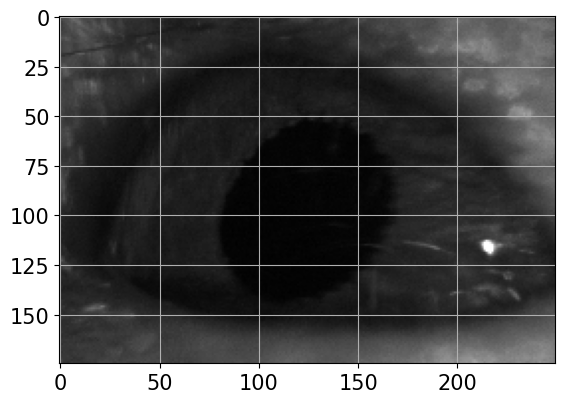

In [14]:
cropped_stack = np.array(stack[:, top:bottom, left:right])
show_one_image(cropped_stack[1230])

In [15]:
def pupil_detection(stack: np.array, contour_shortest: int = 200,
                    contour_longest: int = 700, n_frames=None,
                    clahe_clip: float = 2.0, clahe_grid: tuple = (15,15),
                    gamma: float = 1.30, max_displacement: int = 250) -> tuple:
    """
    Detect the pupil in a stack of images and return the ellipse parameters and contours.
    CLAHE + gamma correction to enhance darker regions.
    Prevent sudden center jumps using max_displacement.

    Returns:
        tuple: (pupil_ellipse, overlay_img, pupil_contours)
    """
    if n_frames is None:
        n_frames = stack.shape[0]
    
    pupil_ellipse = []
    pupil_contours = [] 
    overlay_img = np.zeros((n_frames, stack.shape[1], stack.shape[2]), dtype=np.uint8)

    last_center = None
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)

    for i in tqdm(range(n_frames)):
        # Median blur
        img = cv2.medianBlur(stack[i], ksize=5)

        # CLAHE enhancement
        img_eq = clahe.apply(img)

        # Gamma correction
        img_gamma = np.power(img_eq/255.0, 1/gamma) * 255
        img_gamma = img_gamma.astype(np.uint8)

        # Thresholding
        threshold = (img_gamma.max() - img_gamma.min()) * 0.06 + img_gamma.min()
        _, binary = cv2.threshold(img_gamma, threshold, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
        contours = [c for c in contours if contour_shortest < len(c) < contour_longest]

        if len(contours) > 1:
            # Choose contour closest to previous center if available
            if last_center is not None:
                contours.sort(key=lambda c: np.linalg.norm(c[:,:,0].mean() - last_center[0]) +
                                              np.linalg.norm(c[:,:,1].mean() - last_center[1]))
            else:
                contour_lengths = [len(c) for c in contours]
                index = np.argmax(contour_lengths)
                contours = [contours[index]]
            contours = [contours[0]]

        if len(contours) == 0:
    # 没有检测到时，沿用上一帧结果
            if len(pupil_ellipse) > 0 and pupil_ellipse[-1] is not None:
                ellipse = pupil_ellipse[-1]
                pupil_ellipse.append(ellipse)
                pupil_contours.append(None)
                cv2.ellipse(overlay_img[i], box=ellipse, color=255, thickness=1)
                last_center = ellipse[0]  # 更新中心
            else:
                pupil_ellipse.append(None)
                pupil_contours.append(None)
            continue

        hull = cv2.convexHull(contours[0])
        if len(hull) > 5:
            ellipse = cv2.fitEllipse(hull)
        else:
            ellipse = cv2.fitEllipse(contours[0])

        (x, y), (major, minor), angle = ellipse

        # Prevent sudden center jumps
        if last_center is not None:
            dist = np.sqrt((x - last_center[0])**2 + (y - last_center[1])**2)
            if dist > max_displacement:
                # Option 1: skip this frame
                # pupil_ellipse.append(None)
                # pupil_contours.append(None)
                # continue
                # Option 2: 可以沿用上一帧中心，也可以实现平滑插值
                x, y = last_center
                # continue

        pupil_ellipse.append(((x, y), (major, minor), angle))
        pupil_contours.append(contours)
        cv2.ellipse(overlay_img[i], box=((x, y), (major, minor), angle), color=255, thickness=1)

        last_center = (x, y)

    return pupil_ellipse, overlay_img, pupil_contours


In [16]:
pupil_ellipse, overlay, pupil_contours = pupil_detection(cropped_stack, n_frames=None, gamma=1.30,clahe_clip=2,clahe_grid=(15,15), max_displacement=50)

100%|██████████| 31660/31660 [00:26<00:00, 1208.49it/s]


In [21]:
import cv2
import h5py
import numpy as np
from tqdm import tqdm

def pupil_detection(stack: np.array, contour_shortest: int = 200,
                    contour_longest: int = 700, n_frames=None,
                    clahe_clip: float = 2.0, clahe_grid: tuple = (15,15),
                    gamma: float = 1.30, max_displacement: int = 50,
                    save_path: str = None) -> tuple:
    """
    Detect the pupil in a stack of images and return the ellipse parameters and contours.
    Optionally save results into HDF5.

    Returns:
        tuple: (pupil_ellipse, overlay_img, pupil_contours)
    """
    if n_frames is None:
        n_frames = stack.shape[0]
    
    pupil_ellipse = []
    pupil_contours = [] 
    overlay_img = np.zeros((n_frames, stack.shape[1], stack.shape[2]), dtype=np.uint8)

    last_center = None
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)

    for i in tqdm(range(n_frames)):
        # Median blur
        img = cv2.medianBlur(stack[i], ksize=5)

        # CLAHE enhancement
        img_eq = clahe.apply(img)

        # Gamma correction
        img_gamma = np.power(img_eq/255.0, 1/gamma) * 255
        img_gamma = img_gamma.astype(np.uint8)

        # Thresholding
        threshold = (img_gamma.max() - img_gamma.min()) * 0.06 + img_gamma.min()
        _, binary = cv2.threshold(img_gamma, threshold, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
        contours = [c for c in contours if contour_shortest < len(c) < contour_longest]

        if len(contours) > 1:
            if last_center is not None:
                contours.sort(key=lambda c: np.linalg.norm(c[:,:,0].mean() - last_center[0]) +
                                              np.linalg.norm(c[:,:,1].mean() - last_center[1]))
            else:
                contour_lengths = [len(c) for c in contours]
                index = np.argmax(contour_lengths)
                contours = [contours[index]]
            contours = [contours[0]]

        if len(contours) == 0:
            if len(pupil_ellipse) > 0 and pupil_ellipse[-1] is not None:
                ellipse = pupil_ellipse[-1]
                pupil_ellipse.append(ellipse)
                pupil_contours.append(None)
                cv2.ellipse(overlay_img[i], box=ellipse, color=255, thickness=1)
                last_center = ellipse[0]
            else:
                pupil_ellipse.append(None)
                pupil_contours.append(None)
            continue

        hull = cv2.convexHull(contours[0])
        if len(hull) > 5:
            ellipse = cv2.fitEllipse(hull)
        else:
            ellipse = cv2.fitEllipse(contours[0])

        (x, y), (major, minor), angle = ellipse

        if last_center is not None:
            dist = np.sqrt((x - last_center[0])**2 + (y - last_center[1])**2)
            if dist > max_displacement:
                x, y = last_center

        pupil_ellipse.append(((x, y), (major, minor), angle))
        pupil_contours.append(contours)
        cv2.ellipse(overlay_img[i], box=((x, y), (major, minor), angle), color=255, thickness=1)

        last_center = (x, y)

    # ===== 保存结果到 HDF5 =====
    if save_path is not None:
        with h5py.File(save_path, "a") as f:
            # 转成 numpy 数组方便存储 (None 用 nan 填充)
            ellipses_arr = np.full((n_frames, 5), np.nan, dtype=np.float32)
            for i, e in enumerate(pupil_ellipse):
                if e is not None:
                    (cx, cy), (major, minor), angle = e
                    ellipses_arr[i] = [cx, cy, major, minor, angle]

            f.create_dataset("ellipse", data=ellipses_arr)   # 每一帧的椭圆参数
            f.create_dataset("overlay", data=overlay_img)    # 带椭圆的结果图像

            # 存 metadata
            f.attrs["contour_shortest"] = contour_shortest
            f.attrs["contour_longest"] = contour_longest
            f.attrs["clahe_clip"] = clahe_clip
            f.attrs["clahe_grid"] = str(clahe_grid)
            f.attrs["gamma"] = gamma
            f.attrs["max_displacement"] = max_displacement

        print(f"Results saved to {save_path}")

    return pupil_ellipse, overlay_img, pupil_contours


In [23]:
output_path


'/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250825/pupil_detection_output.avi'

In [24]:
import os
from os.path import join as pjoin

# video_name = os.path.splitext(os.path.basename(video_path))[0]  # 提取视频名
# save_path = pjoin(output_path, f"{video_name}_pupil.h5")
save_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/results/A092_20250825.h5"
# os.makedirs(output_path, exist_ok=True)

pupil_ellipse, overlay, pupil_contours = pupil_detection(cropped_stack, save_path=save_path)

100%|██████████| 31660/31660 [01:27<00:00, 360.73it/s] 


Results saved to /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/results/A092_20250825.h5


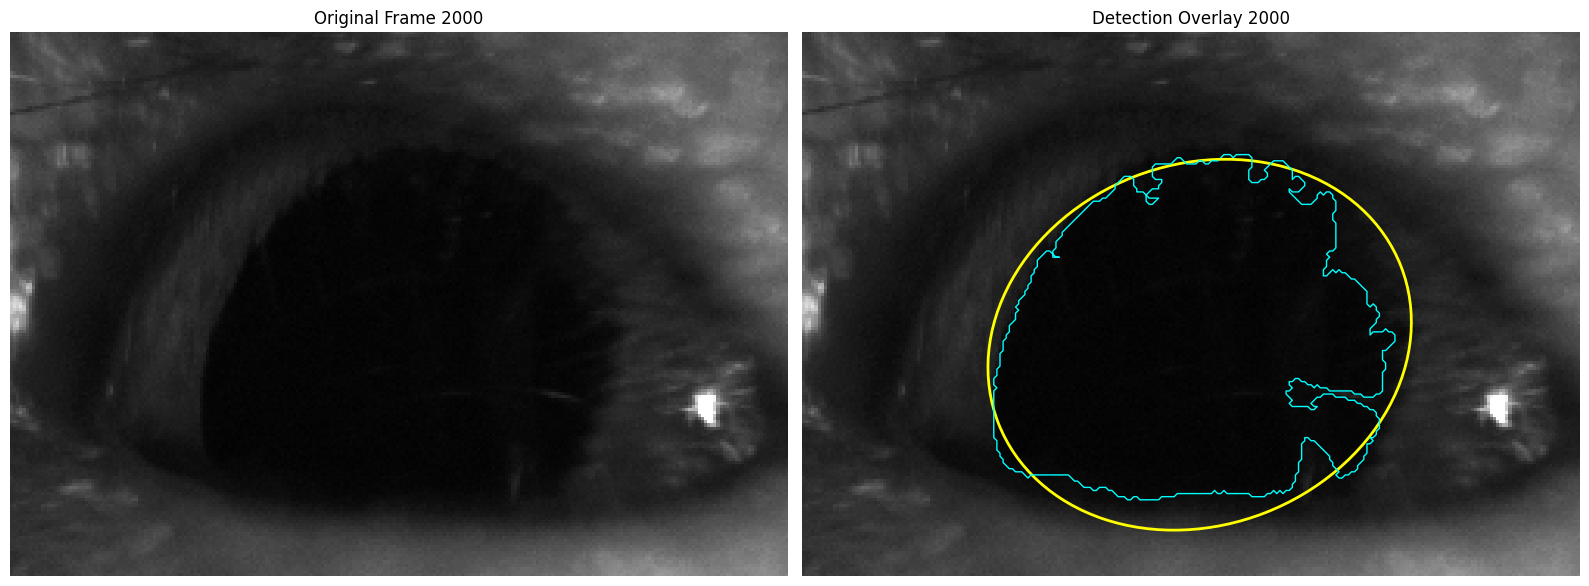

In [17]:
frame_idx =2000

original_frame = cropped_stack[frame_idx]
overlay_frame = overlay[frame_idx]
contours = pupil_contours[frame_idx]
ellipse = pupil_ellipse[frame_idx]

fig, axs = plt.subplots(1, 2, figsize=(16,8))  


axs[0].imshow(original_frame, cmap='gray')
axs[0].set_title(f'Original Frame {frame_idx}')
axs[0].axis('off')

axs[1].imshow(original_frame, cmap='gray')
# axs[1].imshow(overlay_frame, cmap='jet', alpha=0.5)

if contours is not None:
    for contour in contours:
        contour = contour.squeeze()
        axs[1].plot(contour[:,0], contour[:,1], color='cyan', linewidth=1)

if ellipse is not None:
    center, axes_len, angle = ellipse[0], ellipse[1], ellipse[2]
    ellipse_patch = Ellipse(xy=center, width=axes_len[0], height=axes_len[1], angle=angle,
                            edgecolor='yellow', facecolor='none', linewidth=2)
    axs[1].add_patch(ellipse_patch)

axs[1].set_title(f'Detection Overlay {frame_idx}')
axs[1].axis('off')

plt.tight_layout()
plt.show()


In [19]:
from matplotlib.backends.backend_agg import FigureCanvasAgg

output_path = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250825/pupil_detection_output.avi'
fps = 10  
video_size = (right-left, bottom-top) 

fourcc = cv2.VideoWriter_fourcc(*'MJPG')
video_writer = cv2.VideoWriter(output_path, fourcc, fps, video_size)

for frame_idx in tqdm(range(len(cropped_stack))):
# for frame_idx in range(0, 500):
    original_frame = cropped_stack[frame_idx]
    contours = pupil_contours[frame_idx]
    ellipse = pupil_ellipse[frame_idx]
    fig, ax = plt.subplots(figsize=((right-left)/50, (bottom-top)/50), dpi=200)


    ax.imshow(original_frame, cmap='gray')

    if contours is not None:
        for contour in contours:
            contour = contour.squeeze()
            ax.plot(contour[:,0], contour[:,1], color='cyan', linewidth=1)

    if ellipse is not None:
        center, axes_len, angle = ellipse[0], ellipse[1], ellipse[2]
        ellipse_patch = Ellipse(xy=center, width=axes_len[0], height=axes_len[1], angle=angle,
                                edgecolor='yellow', facecolor='none', linewidth=1)
        ax.add_patch(ellipse_patch)

    ax.axis('off')

    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    img = np.frombuffer(canvas.buffer_rgba(), dtype='uint8')
    img = img.reshape(canvas.get_width_height()[::-1] + (4,))  
    img = img[:, :, :3]  

    plt.close(fig) 

    img = cv2.resize(img, video_size)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cv2.putText(
    img_bgr, 
    f"Frame {frame_idx}", 
    (10, 30),  # 左上角坐标
    cv2.FONT_HERSHEY_SIMPLEX, 
    1.0,  # 字体大小
    (0, 255, 0),  # 绿色
    2,  # 粗细
    cv2.LINE_AA
)

    video_writer.write(img_bgr)

video_writer.release()
print(f'Export completed: {output_path}')


100%|██████████| 31660/31660 [18:00<00:00, 29.30it/s]  

Export completed: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250825/pupil_detection_output.avi


### align the triggers

In [32]:
print(save_path)

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/results/A092_20250825.h5


In [28]:
with h5py.File(save_path, "r") as f:
    print("H5 文件里的 key:")
    def print_keys(name):
        print(name)
    f.visit(print_keys)

H5 文件里的 key:
ellipse
overlay
trial_0
trial_0/lick_times
trial_0/trial_results
trial_1
trial_1/lick_times
trial_1/trial_results
trial_10
trial_10/lick_times
trial_10/trial_results
trial_100
trial_100/lick_times
trial_100/trial_results
trial_101
trial_101/lick_times
trial_101/trial_results
trial_102
trial_102/lick_times
trial_102/trial_results
trial_103
trial_103/lick_times
trial_103/trial_results
trial_104
trial_104/lick_times
trial_104/trial_results
trial_105
trial_105/lick_times
trial_105/trial_results
trial_106
trial_106/lick_times
trial_106/trial_results
trial_107
trial_107/lick_times
trial_107/trial_results
trial_108
trial_108/lick_times
trial_108/trial_results
trial_109
trial_109/lick_times
trial_109/trial_results
trial_11
trial_11/lick_times
trial_11/trial_results
trial_110
trial_110/lick_times
trial_110/trial_results
trial_111
trial_111/lick_times
trial_111/trial_results
trial_112
trial_112/lick_times
trial_112/trial_results
trial_113
trial_113/lick_times
trial_113/trial_results

In [25]:
with h5py.File(save_path, "r") as f:
    print("H5 文件里的 key:")
    def print_keys(name):
        print(name)
    f.visit(print_keys)
with h5py.File(save_path, "r") as f:
    # 读取椭圆参数
    ellipse_data = f["ellipse"][:]
    print("ellipse shape:", ellipse_data.shape)
    
    # 读取 overlay 图
    overlay_data = f["overlay"][:]
    print("overlay shape:", overlay_data.shape)

H5 文件里的 key:
ellipse
overlay
trial_0
trial_0/lick_times
trial_0/trial_results
trial_1
trial_1/lick_times
trial_1/trial_results
trial_10
trial_10/lick_times
trial_10/trial_results
trial_100
trial_100/lick_times
trial_100/trial_results
trial_101
trial_101/lick_times
trial_101/trial_results
trial_102
trial_102/lick_times
trial_102/trial_results
trial_103
trial_103/lick_times
trial_103/trial_results
trial_104
trial_104/lick_times
trial_104/trial_results
trial_105
trial_105/lick_times
trial_105/trial_results
trial_106
trial_106/lick_times
trial_106/trial_results
trial_107
trial_107/lick_times
trial_107/trial_results
trial_108
trial_108/lick_times
trial_108/trial_results
trial_109
trial_109/lick_times
trial_109/trial_results
trial_11
trial_11/lick_times
trial_11/trial_results
trial_110
trial_110/lick_times
trial_110/trial_results
trial_111
trial_111/lick_times
trial_111/trial_results
trial_112
trial_112/lick_times
trial_112/trial_results
trial_113
trial_113/lick_times
trial_113/trial_results

In [ ]:
import numpy as np
import pandas as pd
import h5py

# read the trigger file
trigger_file = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250825/2025-08-25_a092.txt'
# 使用正则匹配任意空白分隔
df = pd.read_csv(trigger_file, sep=r'\s+', header=0)
print(df.columns)
# 可选：重命名列
df.columns = ["time_ms", "trigger_voltage_V"]
# df = pd.read_csv(trigger_file, sep="\t", header=None, names=["time(ms)", "trigger_voltage(V)"])
voltage = df['trigger_voltage_V'].values
time_ms = df['time_ms'].values

# read the h5 file and process
with h5py.File(save_path, 'r+') as f:  # 'r+' 可读可写
    ellipse = f['ellipse'][:]
    overlay = f['overlay'][:]

    # 找 trigger 变化点
    voltage_diff = np.diff(voltage)
    change_idx = np.where(voltage_diff > 1)[0] + 1  # 上升沿
    change_idx = np.insert(change_idx, 0, 0)  # 把第一帧加进去
    print("Trigger 变化点索引:", change_idx)

    trigger_times = time_ms[change_idx]
    trigger_intervals = np.diff(trigger_times)  # 单位：ms
    print("每个 trigger 之间的间隔 (ms):", trigger_intervals)

    # 切分 pupil 数据
    pupil_segments = []
    overlay_segments = []
    start_idx = 0
    for idx in change_idx:
        pupil_segments.append(ellipse[start_idx:idx])
        overlay_segments.append(overlay[start_idx:idx])
        start_idx = idx
    pupil_segments.append(ellipse[start_idx:])
    overlay_segments.append(overlay[start_idx:])
    print(f"切分得到 {len(pupil_segments)} 段 pupil 数据")

    # 拼接切分后的数据
    segmented_ellipse = np.concatenate(pupil_segments, axis=0)
    segmented_overlay = np.concatenate(overlay_segments, axis=0)

    # 保存到原 H5 文件里
    for key in ['segmented_ellipse', 'segmented_overlay']:
        if key in f:
            del f[key]  # 先删除已有 key
    f.create_dataset('segmented_ellipse', data=segmented_ellipse)
    f.create_dataset('segmented_overlay', data=segmented_overlay)

print("保存完成，H5 文件包含：ellipse, overlay, segmented_ellipse, segmented_overlay")


Index(['time(ms)', 'trigger_voltage(V)'], dtype='object')
Trigger 变化点索引: [    0    58   114   171   228   284   341   398   454   511   568   624
   681   738   795   851   908   964  1021  1078  1135  1192  1250  1307
  1364  1421  1478  1536  1594  1651  1708  1766  1824  1882  1940  1998
  2056  2114  2171  2230  2288  2346  2404  2462  2520  2579  2637  2695
  2754  2812  2871  2929  2988  3047  3106  3165  3225  3284  3343  3402
  3462  3521  3581  3640  3700  3759  3818  3877  3937  3997  4056  4115
  4175  4235  4295  4355  4415  4474  4534  4594  4654  4714  4774  4834
  4894  4954  5014  5074  5135  5195  5255  5316  5376  5437  5497  5558
  5618  5679  5740  5801  5862  5923  5984  6045  6107  6168  6229  6291
  6352  6414  6475  6537  6599  6660  6722  6783  6845  6907  6969  7030
  7092  7154  7216  7278  7340  7402  7464  7527  7589  7651  7714  7776
  7838  7901  7964  8026  8089  8152  8215  8278  8342  8405  8468  8531
  8594  8657  8721  8784  8847  8910  8974  9037  9

In [ ]:
import numpy as np
import pandas as pd
import h5py

# read the trigger file
trigger_file = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250805/2025-08-05_a092.txt'
# 使用正则匹配任意空白分隔
df = pd.read_csv(trigger_file, sep=r'\s+', header=0)
print("原始列:", df.columns)

# 重命名列，方便使用
df.columns = ["time_ms", "trigger_voltage_V"]
voltage = df['trigger_voltage_V'].values
time_ms = df['time_ms'].values

# read the h5 file and process
with h5py.File(save_path, 'a') as f:  # 'r+' 可读可写
    ellipse = f['ellipse'][:]
    overlay = f['overlay'][:]

    # 找 trigger 上升沿
    voltage_diff = np.diff(voltage)
    change_idx = np.where(voltage_diff > 1)[0] + 1  # 上升沿索引
    change_idx = np.insert(change_idx, 0, 0)  # 把第一帧加进去
    print("Trigger 变化点索引:", change_idx)

    trigger_times = time_ms[change_idx]
    trigger_intervals = np.diff(trigger_times)  # 单位：ms
    print("每个 trigger 之间的间隔 (ms):", trigger_intervals)

    # ======= 创建 segmented group =======
    if "segmented_ellipse" in f:
        del f["segmented_ellipse"]
    if "segmented_overlay" in f:
        del f["segmented_overlay"]

    grp_ellipse = f.create_group("segmented_ellipse")
    grp_overlay = f.create_group("segmented_overlay")

    # 按 trigger 切分并保存
    start_idx = 0
    for trial_id, idx in enumerate(change_idx[1:], start=0):
        seg_e = ellipse[start_idx:idx]
        seg_o = overlay[start_idx:idx]
        grp_ellipse.create_dataset(f"trial_{trial_id}", data=seg_e)
        grp_overlay.create_dataset(f"trial_{trial_id}", data=seg_o)
        start_idx = idx

    # 最后一段（从最后一个 trigger 到结束）
    seg_e = ellipse[start_idx:]
    seg_o = overlay[start_idx:]
    grp_ellipse.create_dataset(f"trial_{len(change_idx)-1}", data=seg_e)
    grp_overlay.create_dataset(f"trial_{len(change_idx)-1}", data=seg_o)

print("✅ 保存完成，H5 文件里现在有 segmented_ellipse/trial_x 和 segmented_overlay/trial_x")


原始列: Index(['time(ms)', 'trigger_voltage(V)'], dtype='object')
Trigger 变化点索引: [    0    58   114   171   228   284   341   398   454   511   568   624
   681   738   795   851   908   964  1021  1078  1135  1192  1250  1307
  1364  1421  1478  1536  1594  1651  1708  1766  1824  1882  1940  1998
  2056  2114  2171  2230  2288  2346  2404  2462  2520  2579  2637  2695
  2754  2812  2871  2929  2988  3047  3106  3165  3225  3284  3343  3402
  3462  3521  3581  3640  3700  3759  3818  3877  3937  3997  4056  4115
  4175  4235  4295  4355  4415  4474  4534  4594  4654  4714  4774  4834
  4894  4954  5014  5074  5135  5195  5255  5316  5376  5437  5497  5558
  5618  5679  5740  5801  5862  5923  5984  6045  6107  6168  6229  6291
  6352  6414  6475  6537  6599  6660  6722  6783  6845  6907  6969  7030
  7092  7154  7216  7278  7340  7402  7464  7527  7589  7651  7714  7776
  7838  7901  7964  8026  8089  8152  8215  8278  8342  8405  8468  8531
  8594  8657  8721  8784  8847  8910  8974  90

In [30]:
import numpy as np
import pandas as pd
import h5py

# read the trigger file
trigger_file = '/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250805/2025-08-05_a092.txt'
df = pd.read_csv(trigger_file, sep=r'\s+', header=0)
print("原始列:", df.columns)

# 重命名列
df.columns = ["time_ms", "trigger_voltage_V"]
voltage = df['trigger_voltage_V'].values
time_ms = df['time_ms'].values

# read the h5 file and process
with h5py.File(save_path, 'a') as f:  # 'r+' 可读可写
    ellipse = f['ellipse'][:]
    overlay = f['overlay'][:]

    # 找 trigger 上升沿
    voltage_diff = np.diff(voltage)
    change_idx = np.where(voltage_diff > 1)[0] + 1
    change_idx = np.insert(change_idx, 0, 0)
    print("Trigger 变化点索引:", change_idx)

    trigger_times = time_ms[change_idx]
    trigger_intervals = np.diff(trigger_times)  # 单位：ms
    print("每个 trigger 之间的间隔 (ms):", trigger_intervals)



    # 按 trigger 切分并保存
    start_idx = 0
    for trial_id, idx in enumerate(change_idx[1:], start=0):
        seg_e = ellipse[start_idx:idx]
        seg_o = overlay[start_idx:idx]

        trial_key = f"trial_{trial_id}"
        if trial_key in f:
            grp = f[trial_key]  # 已存在就复用
        else:
            grp = f.create_group(trial_key)

        # 如果已经存在 ellipse/overlay dataset，可以删除再写
        if "ellipse" in grp:
            del grp["ellipse"]
        if "overlay" in grp:
            del grp["overlay"]

        grp.create_dataset("ellipse", data=seg_e)
        grp.create_dataset("overlay", data=seg_o)

        start_idx = idx

    # 最后一段
    seg_e = ellipse[start_idx:]
    seg_o = overlay[start_idx:]
    trial_key = f"trial_{len(change_idx)-1}"
    if trial_key in f:
        grp = f[trial_key]
    else:
        grp = f.create_group(trial_key)

    if "ellipse" in grp:
        del grp["ellipse"]
    if "overlay" in grp:
        del grp["overlay"]

    grp.create_dataset("ellipse", data=seg_e)
    grp.create_dataset("overlay", data=seg_o)

print("✅ 保存完成，H5 文件里现在每个 trial_x 下有 ellipse 和 overlay")


原始列: Index(['time(ms)', 'trigger_voltage(V)'], dtype='object')
Trigger 变化点索引: [    0    58   114   171   228   284   341   398   454   511   568   624
   681   738   795   851   908   964  1021  1078  1135  1192  1250  1307
  1364  1421  1478  1536  1594  1651  1708  1766  1824  1882  1940  1998
  2056  2114  2171  2230  2288  2346  2404  2462  2520  2579  2637  2695
  2754  2812  2871  2929  2988  3047  3106  3165  3225  3284  3343  3402
  3462  3521  3581  3640  3700  3759  3818  3877  3937  3997  4056  4115
  4175  4235  4295  4355  4415  4474  4534  4594  4654  4714  4774  4834
  4894  4954  5014  5074  5135  5195  5255  5316  5376  5437  5497  5558
  5618  5679  5740  5801  5862  5923  5984  6045  6107  6168  6229  6291
  6352  6414  6475  6537  6599  6660  6722  6783  6845  6907  6969  7030
  7092  7154  7216  7278  7340  7402  7464  7527  7589  7651  7714  7776
  7838  7901  7964  8026  8089  8152  8215  8278  8342  8405  8468  8531
  8594  8657  8721  8784  8847  8910  8974  90

In [31]:
with h5py.File(save_path, "r") as f:
    print("H5 文件里的 key:")
    def print_keys(name):
        print(name)
    f.visit(print_keys)
# with h5py.File(save_path, "r") as f:
#     # 读取椭圆参数
#     ellipse_data = f["ellipse"][:]
#     print("ellipse shape:", ellipse_data.shape)
    
#     # 读取 overlay 图
#     overlay_data = f["overlay"][:]
#     print("overlay shape:", overlay_data.shape)

H5 文件里的 key:
ellipse
overlay
trial_0
trial_0/ellipse
trial_0/lick_times
trial_0/overlay
trial_0/trial_results
trial_1
trial_1/ellipse
trial_1/lick_times
trial_1/overlay
trial_1/trial_results
trial_10
trial_10/ellipse
trial_10/lick_times
trial_10/overlay
trial_10/trial_results
trial_100
trial_100/ellipse
trial_100/lick_times
trial_100/overlay
trial_100/trial_results
trial_101
trial_101/ellipse
trial_101/lick_times
trial_101/overlay
trial_101/trial_results
trial_102
trial_102/ellipse
trial_102/lick_times
trial_102/overlay
trial_102/trial_results
trial_103
trial_103/ellipse
trial_103/lick_times
trial_103/overlay
trial_103/trial_results
trial_104
trial_104/ellipse
trial_104/lick_times
trial_104/overlay
trial_104/trial_results
trial_105
trial_105/ellipse
trial_105/lick_times
trial_105/overlay
trial_105/trial_results
trial_106
trial_106/ellipse
trial_106/lick_times
trial_106/overlay
trial_106/trial_results
trial_107
trial_107/ellipse
trial_107/lick_times
trial_107/overlay
trial_107/trial_res

In [480]:
import matplotlib.pyplot as plt

def plot_pupil_trial(ellipse_df, trial_idx=0, trial_column="trial"):
    """
    画单个 trial 的 pupil size & 位移曲线
    """
    # 选择一个 trial
    trial_data = ellipse_df[ellipse_df[trial_column] == trial_idx]

    if trial_data.empty:
        print(f"Trial {trial_idx} 不存在")
        return
    
    time = trial_data["time(ms)"].values
    size = trial_data["pupil_size"].values
    x = trial_data["center_x"].values
    y = trial_data["center_y"].values

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # 瞳孔大小
    axs[0].plot(time, size, color="blue")
    axs[0].set_ylabel("Pupil size")
    axs[0].set_title(f"Pupil size trace (Trial {trial_idx})")

    # 瞳孔位移
    axs[1].plot(time, x - x[0], label="X displacement")
    axs[1].plot(time, y - y[0], label="Y displacement")
    axs[1].set_ylabel("Displacement (px)")
    axs[1].set_xlabel("Time (ms)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


In [481]:
plot_pupil_trial(ellipse_df, trial_idx=5)  # 画第5个trial


NameError: name 'ellipse_df' is not defined

In [482]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_pupil_trial_by_group(h5_path,
                              trial_idx=0,
                              fps=None,
                              measure='area',
                              smooth=None):
    seg_key = f'segment_{trial_idx}/ellipse'
    with h5py.File(h5_path, 'r') as f:
        if seg_key not in f:
            raise KeyError(f"H5 里没有 {seg_key}")
        seg = f[seg_key][:]  # (M,5)

    x, y, major, minor, angle = seg.T

    if measure == 'area':
        size = np.pi * (major/2.0) * (minor/2.0)
        ylab_size = 'Pupil area (px^2)'
    elif measure == 'major':
        size = major; ylab_size = 'Major axis (px)'
    elif measure == 'minor':
        size = minor; ylab_size = 'Minor axis (px)'
    elif measure == 'diameter':
        size = (major + minor) / 2.0; ylab_size = 'Mean diameter (px)'
    else:
        raise ValueError("measure 需为 'area' | 'major' | 'minor' | 'diameter'")

    n = len(seg)
    if fps is None:
        t = np.arange(n); xlab = 'Frame'
    else:
        t = np.arange(n) / float(fps) * 1000.0; xlab = 'Time (ms)'

    valid = np.isfinite(x) & np.isfinite(y)
    if valid.any():
        i0 = np.argmax(valid); x0, y0 = x[i0], y[i0]
    else:
        x0 = y0 = 0.0
    dx = x - x0; dy = y - y0

    if smooth is not None:
        win, poly = smooth
        if win % 2 == 0: win += 1
        from scipy.signal import savgol_filter
        def _smooth(a, fill=0.0):
            aa = np.nan_to_num(a, nan=fill)
            return savgol_filter(aa, win, poly, mode='interp')
        size = _smooth(size, np.nanmedian(size) if np.isfinite(size).any() else 0.0)
        dx = _smooth(dx, 0.0); dy = _smooth(dy, 0.0)

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axs[0].plot(t, size)
    axs[0].set_ylabel(ylab_size)
    axs[0].set_title(f'Trial {trial_idx} — pupil {measure}')

    axs[1].plot(t, dx, label='X displacement')
    axs[1].plot(t, dy, label='Y displacement')
    axs[1].set_ylabel('Displacement (px)')
    axs[1].set_xlabel(xlab)
    axs[1].legend()
    axs[0].axvline(0, ls='--', alpha=0.4)
    axs[1].axvline(0, ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


In [483]:
print(save_path)

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250805/pupil_detection_output/2025-08-05_a092_pupil.h5


In [484]:
plot_pupil_trial_by_group(save_path,
                              trial_idx=0,
                              fps=60,)

KeyError: 'H5 里没有 segment_0/ellipse'

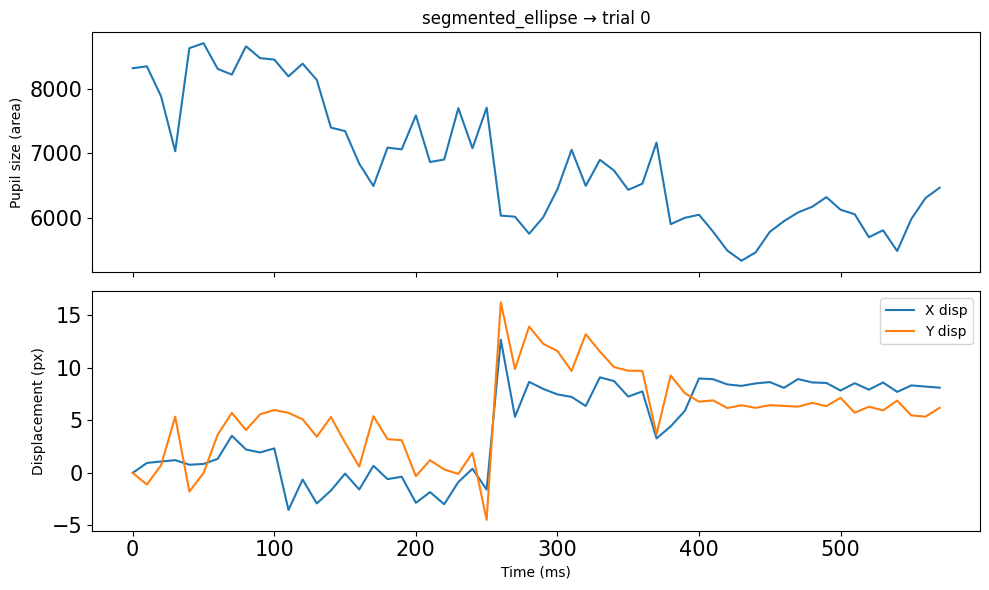

In [488]:
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt

def _pupil_size(seg, metric='area'):
    """
    seg: (T,5) -> [x, y, major, minor, angle]
    metric: 'area' | 'major' | 'minor' | 'geom_mean'
    """
    major = seg[:, 2]
    minor = seg[:, 3]
    if metric == 'area':
        return np.pi * (major/2.0) * (minor/2.0)    # 注意 major/minor 是整轴长(直径)
    elif metric == 'major':
        return major
    elif metric == 'minor':
        return minor
    elif metric == 'geom_mean':
        return np.sqrt(major * minor)
    else:
        raise ValueError("metric ∈ {'area','major','minor','geom_mean'}")

def _numeric_key(name: str):
    """把 'segment_12' / 'trial3' 这种按数字排序；没有数字的放最后。"""
    m = re.findall(r'\d+', name)
    return int(m[-1]) if m else 10**9

def plot_pupil_trial_from_segmented_h5(
    h5_path: str,
    trial_id: int = 0,
    seg_group: str = "segmented_ellipse",
    metric: str = "area",
    fps: float | None = None,
    dt_ms: float | None = None,
    ref: str = "first"       # 'first' 用本 trial 第一帧非 NaN 作为位移参考；或 'mean'
):
    """
    从 H5 的 segmented_ellipse 读取指定 trial 并绘制：
      1) pupil size vs time
      2) center displacement vs time

    要求 H5 结构为：
      /segmented_ellipse/segment_0, segment_1, ...   (每个 dataset 形状 (Ti,5))
    若你的子节点不是 'segment_x' 命名也没关系，会按名字里的数字排序。
    """
    with h5py.File(h5_path, "r") as f:
        if seg_group not in f:
            raise KeyError(f"H5 中不存在分段组 '{seg_group}'，可用 keys: {list(f.keys())}")

        node = f[seg_group]
        if isinstance(node, h5py.Group):
            seg_names = sorted(list(node.keys()), key=_numeric_key)
            if len(seg_names) == 0:
                raise ValueError(f"组 '{seg_group}' 为空。")
            if trial_id < 0 or trial_id >= len(seg_names):
                raise IndexError(f"trial_id={trial_id} 超界，范围 0~{len(seg_names)-1}")
            name = seg_names[trial_id]
            seg = node[name][:]   # (T,5)
        else:
            # 如果不是 group，而是 dataset（很少见，且需要 vlen 存法），做兼容处理
            try:
                seg = node[trial_id]
                # 确保成二维 (T,5)
                seg = np.asarray(seg)
            except Exception:
                raise TypeError(
                    f"'{seg_group}' 不是 Group，也无法按 trial 索引读取。"
                    " 请确认 segmented_ellipse 是以 group/segment_x 方式保存的。"
                )

    if seg.ndim != 2 or seg.shape[1] < 5:
        raise ValueError(f"读取到的 trial 数据形状不对：{seg.shape}，期望 (T,5)")

    # 时间轴
    T = seg.shape[0]
    if dt_ms is not None:
        t = np.arange(T, dtype=float) * float(dt_ms)
        xlab = "Time (ms)"
    elif fps is not None:
        t = np.arange(T, dtype=float) * (1000.0/float(fps))
        xlab = "Time (ms)"
    else:
        t = np.arange(T, dtype=float)
        xlab = "Frame"

    # 曲线
    size = _pupil_size(seg, metric=metric)
    x = seg[:, 0]
    y = seg[:, 1]

    # 位移参考
    if ref == "first":
        valid0 = np.where(~(np.isnan(x) | np.isnan(y)))[0]
        x0, y0 = (x[valid0[0]], y[valid0[0]]) if len(valid0) else (0.0, 0.0)
    elif ref == "mean":
        x0, y0 = np.nanmean(x), np.nanmean(y)
    else:
        raise ValueError("ref 必须是 'first' 或 'mean'")

    dx = x - x0
    dy = y - y0

    # 画图
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axs[0].plot(t, size)
    axs[0].set_ylabel(f"Pupil size ({metric})")
    axs[0].set_title(f"{seg_group} → trial {trial_id}")

    axs[1].plot(t, dx, label="X disp")
    axs[1].plot(t, dy, label="Y disp")
    axs[1].set_ylabel("Displacement (px)")
    axs[1].set_xlabel(xlab)
    axs[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# ==== 用法示例 ====
h5_path = save_path
plot_pupil_trial_from_segmented_h5(h5_path, trial_id=0, seg_group="segmented_ellipse",
                                   metric="area", fps=100, ref="first")


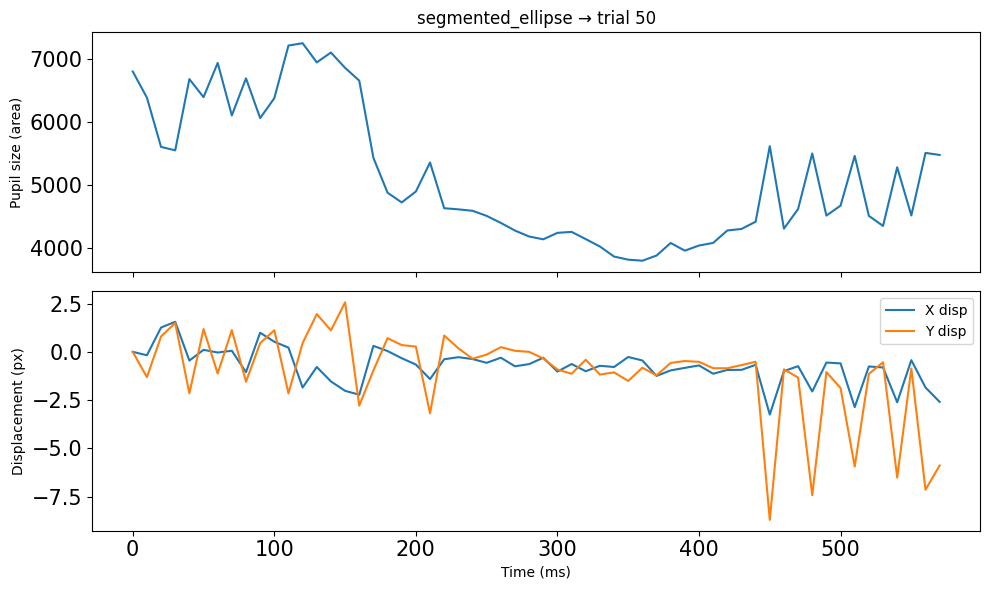

In [490]:
h5_path = save_path
plot_pupil_trial_from_segmented_h5(h5_path, trial_id=50, seg_group="segmented_ellipse",
                                   metric="area", fps=100, ref="first")

In [489]:
import h5py



with h5py.File(save_path, "r") as f:
    def print_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"[DATASET] {name}: shape={obj.shape}, dtype={obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"[GROUP] {name}")
    f.visititems(print_h5)


[DATASET] ellipse: shape=(18979, 5), dtype=float32
[DATASET] overlay: shape=(18979, 175, 250), dtype=uint8
[GROUP] segmented_ellipse
[DATASET] segmented_ellipse/trial_0: shape=(58, 5), dtype=float32
[DATASET] segmented_ellipse/trial_1: shape=(56, 5), dtype=float32
[DATASET] segmented_ellipse/trial_10: shape=(56, 5), dtype=float32
[DATASET] segmented_ellipse/trial_100: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_101: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_102: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_103: shape=(62, 5), dtype=float32
[DATASET] segmented_ellipse/trial_104: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_105: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_106: shape=(62, 5), dtype=float32
[DATASET] segmented_ellipse/trial_107: shape=(61, 5), dtype=float32
[DATASET] segmented_ellipse/trial_108: shape=(62, 5), dtype=float32
[DATASET] segmented_ellipse/trial_109: shape=(61, 5), dt